In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
# Load data
df = pd.read_csv('../data/data.csv')

# Remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

# Feature Engineering: Create new features
df['water_cement_ratio'] = df['water'] / df['cement']
df['total_binder'] = df['cement'] + df['slag'] + df['flyash']

# Features and target
X = df.drop('csMPa', axis=1)
y = df['csMPa']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Shape after removing duplicates: (1005, 9)
Training samples: 804
Test samples: 201


In [3]:
# Train baseline model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} MPa")
print(f"RMSE: {rmse:.2f} MPa")
print(f"R² Score: {r2:.4f}")

MAE: 3.43 MPa
RMSE: 4.89 MPa
R² Score: 0.9198


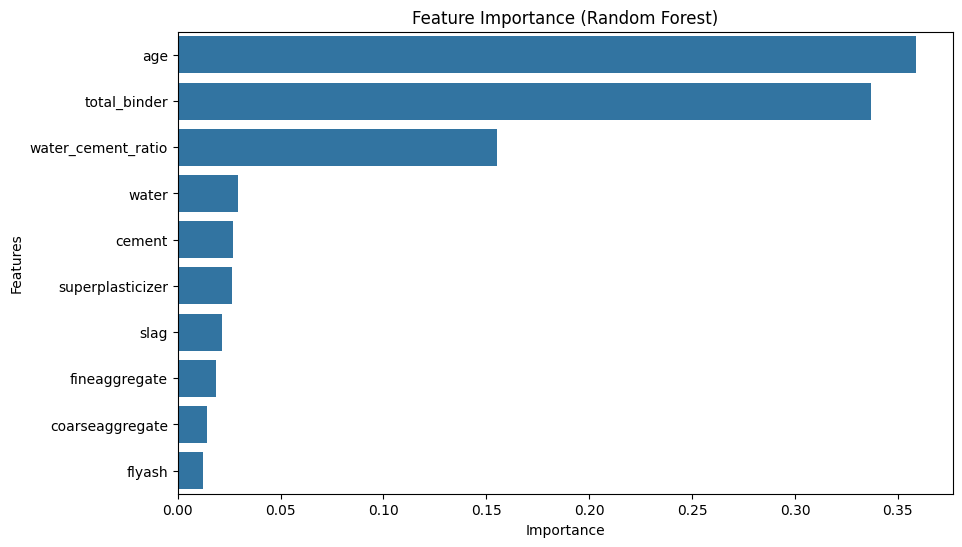

age                   0.358685
total_binder          0.336741
water_cement_ratio    0.155365
water                 0.029315
cement                0.026706
superplasticizer      0.026528
slag                  0.021462
fineaggregate         0.018850
coarseaggregate       0.014160
flyash                0.012189
dtype: float64


In [4]:
# Feature Importance
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

print(feat_imp)

In [5]:
# pip install xgboost

In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost -> MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | R²: {r2_xgb:.4f}")

XGBoost -> MAE: 2.90 | RMSE: 4.33 | R²: 0.9372


In [7]:
# Final Model
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final XGBoost -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}")

Final XGBoost -> MAE: 2.57 | RMSE: 4.07 | R²: 0.9445


In [8]:
# Create model folder if not exists
import os
os.makedirs('../model', exist_ok=True)

# Save model
joblib.dump(model, '../model/xgboost_concrete_model.pkl')

# Save feature names (very important for Streamlit)
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../model/feature_names.pkl')

print("✅ Model saved successfully!")
print("Features:", feature_names)

✅ Model saved successfully!
Features: ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age', 'water_cement_ratio', 'total_binder']
